In [1]:
!pip install xgboost lightgbm -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(
    "../data/processed/final_featured_sales.csv"
)

print(df.shape)

(6435, 42)


### Remove Non-Numeric Columns

In [4]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Quarter',
       'Day', 'DayOfWeek', 'WeekendFlag', 'Festival_Flag', 'Festival_Name',
       'Festival_Score', 'Days_To_Festival', 'Festival_Week', 'Festival_Month',
       'Festival_Impact_Score', 'Pre_Festival_Flag', 'Post_Festival_Flag',
       'Trend_Score', 'Mention_Count', 'Engagement_Rate', 'Sentiment_Score',
       'Influencer_Promotion_Flag', 'Viral_Campaign_Flag', 'Lag_1', 'Lag_4',
       'Lag_12', 'Rolling_Mean_4', 'Rolling_Std_4', 'Moving_Average_8',
       'Festival_Trend', 'Festival_Sentiment', 'Trend_Engagement',
       'Sales_Growth', 'Store_Avg_Sales', 'Store_Sales_Rank'],
      dtype='object')

Convert Festival Name

In [5]:
df = pd.get_dummies(
    df,
    columns=["Festival_Name"],
    drop_first=True
)

Remove Date

In [6]:
df.drop(
    columns=["Date"],
    inplace=True
)

Define Features and Target

In [7]:
TARGET = "Weekly_Sales"

X = df.drop(
    columns=[TARGET]
)

y = df[TARGET]

print(X.shape)

(6435, 52)


Train-Test Split

In [8]:
split_index = int(
    len(df) * 0.8
)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(5148, 52)
(1287, 52)


Evaluation Function

In [9]:
def evaluate_model(
    model,
    X_test,
    y_test
):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mape = np.mean(
        np.abs(
            (y_test - predictions)
            /
            y_test
        )
    ) * 100

    r2 = r2_score(
        y_test,
        predictions
    )

    return {

        "MAE": mae,

        "RMSE": rmse,

        "MAPE": mape,

        "R2": r2

    }

### MODEL 1: RANDOM FOREST

In [10]:
rf_model = RandomForestRegressor(

    n_estimators=300,

    max_depth=12,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [11]:
rf_results = evaluate_model(

    rf_model,

    X_test,

    y_test

)

rf_results

{'MAE': 13207.547953813651,
 'RMSE': np.float64(24101.286107596665),
 'MAPE': np.float64(1.7807781992326472),
 'R2': 0.9961622576805906}

### MODEL 2: XGBOOST

In [12]:
xgb_model = XGBRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42

)

In [13]:
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [14]:
xgb_results = evaluate_model(

    xgb_model,

    X_test,

    y_test

)

xgb_results

{'MAE': 13147.24003253691,
 'RMSE': np.float64(22407.847357886883),
 'MAPE': np.float64(1.7689456717796763),
 'R2': 0.996682616735042}

### MODEL 3: LIGHTGBM

In [15]:
lgbm_model = LGBMRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    random_state=42

)

In [16]:
lgbm_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001970 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4937
[LightGBM] [Info] Number of data points in the train set: 5148, number of used features: 50
[LightGBM] [Info] Start training from score 1117983.530883
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [17]:
lgbm_results = evaluate_model(

    lgbm_model,

    X_test,

    y_test

)

lgbm_results

{'MAE': 13236.23012188503,
 'RMSE': np.float64(23601.22644171155),
 'MAPE': np.float64(1.7983041497761743),
 'R2': 0.9963198584943007}

Model Comparison Table

In [18]:
comparison = pd.DataFrame({

    "Random Forest": rf_results,

    "XGBoost": xgb_results,

    "LightGBM": lgbm_results

}).T

comparison

,MAE,RMSE,MAPE,R2
Random Forest,13207.547954,24101.286108,1.780778,0.996162
XGBoost,13147.240033,22407.847358,1.768946,0.996683
LightGBM,13236.230122,23601.226442,1.798304,0.996320


Sort by R²

In [19]:
comparison.sort_values(
    by="R2",
    ascending=False
)

,MAE,RMSE,MAPE,R2
XGBoost,13147.240033,22407.847358,1.768946,0.996683
LightGBM,13236.230122,23601.226442,1.798304,0.996320
Random Forest,13207.547954,24101.286108,1.780778,0.996162


Visualize Model Performance

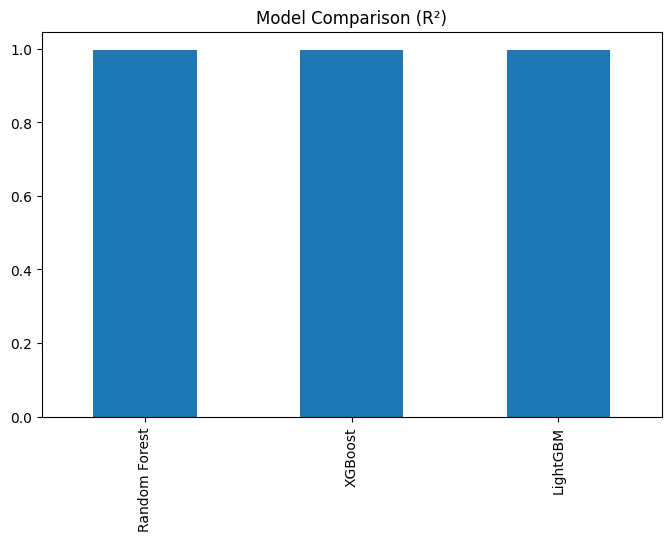

In [20]:
import matplotlib.pyplot as plt

comparison["R2"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Model Comparison (R²)"
)

plt.show()

Save Best Model

In [21]:
import joblib

In [22]:
models = {

    "RandomForest": (
        rf_model,
        rf_results["R2"]
    ),

    "XGBoost": (
        xgb_model,
        xgb_results["R2"]
    ),

    "LightGBM": (
        lgbm_model,
        lgbm_results["R2"]
    )

}

best_model_name = max(
    models,
    key=lambda x: models[x][1]
)

best_model = models[
    best_model_name
][0]

print(
    "Best Model:",
    best_model_name
)

Best Model: XGBoost


In [23]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder created!")

Models folder created!


In [24]:
joblib.dump(

    best_model,

    "../models/best_model.pkl"

)

print(
    "Best model saved!"
)

Best model saved!


Save Comparison Report

In [25]:
comparison.to_csv(
    "../outputs/model_comparison.csv"
)

comparison

,MAE,RMSE,MAPE,R2
Random Forest,13207.547954,24101.286108,1.780778,0.996162
XGBoost,13147.240033,22407.847358,1.768946,0.996683
LightGBM,13236.230122,23601.226442,1.798304,0.996320
